# Notebook 07: Environmental Impact — Air Quality Analysis
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Analyze air quality correlations with weather parameters

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR    = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA, parse_dates=['last_updated'])
print(f"Loaded: {df.shape}")

# Air quality columns
aq_cols = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10',
    'air_quality_us-epa-index',
    'air_quality_gb-defra-index'
]

weather_cols = [
    'temperature_celsius', 'humidity', 'pressure_mb',
    'wind_kph', 'precip_mm', 'visibility_km',
    'uv_index', 'cloud'
]

print(f"Air quality columns: {len(aq_cols)}")
print(f"Weather columns: {len(weather_cols)}")

Loaded: (144822, 39)
Air quality columns: 8
Weather columns: 8


## 1. Air Quality Overview

In [8]:
# Basic stats for air quality
aq_stats = df[aq_cols].describe().round(2)
print("Air Quality Statistics:")
print(aq_stats.to_string())

Air Quality Statistics:
       air_quality_Carbon_Monoxide  air_quality_Ozone  air_quality_Nitrogen_dioxide  air_quality_Sulphur_dioxide  air_quality_PM2.5  air_quality_PM10  air_quality_us-epa-index  air_quality_gb-defra-index
count                    144822.00          144822.00                     144822.00                    144822.00          144822.00         144822.00                 144822.00                   144822.00
mean                        447.16              57.50                         14.76                        10.07              19.65             29.68                      1.68                        2.57
std                         739.84              30.42                         23.23                        34.59              16.74             26.68                      0.93                        2.42
min                       -9999.00               0.00                          0.00                     -9999.00               0.17            -36.61           

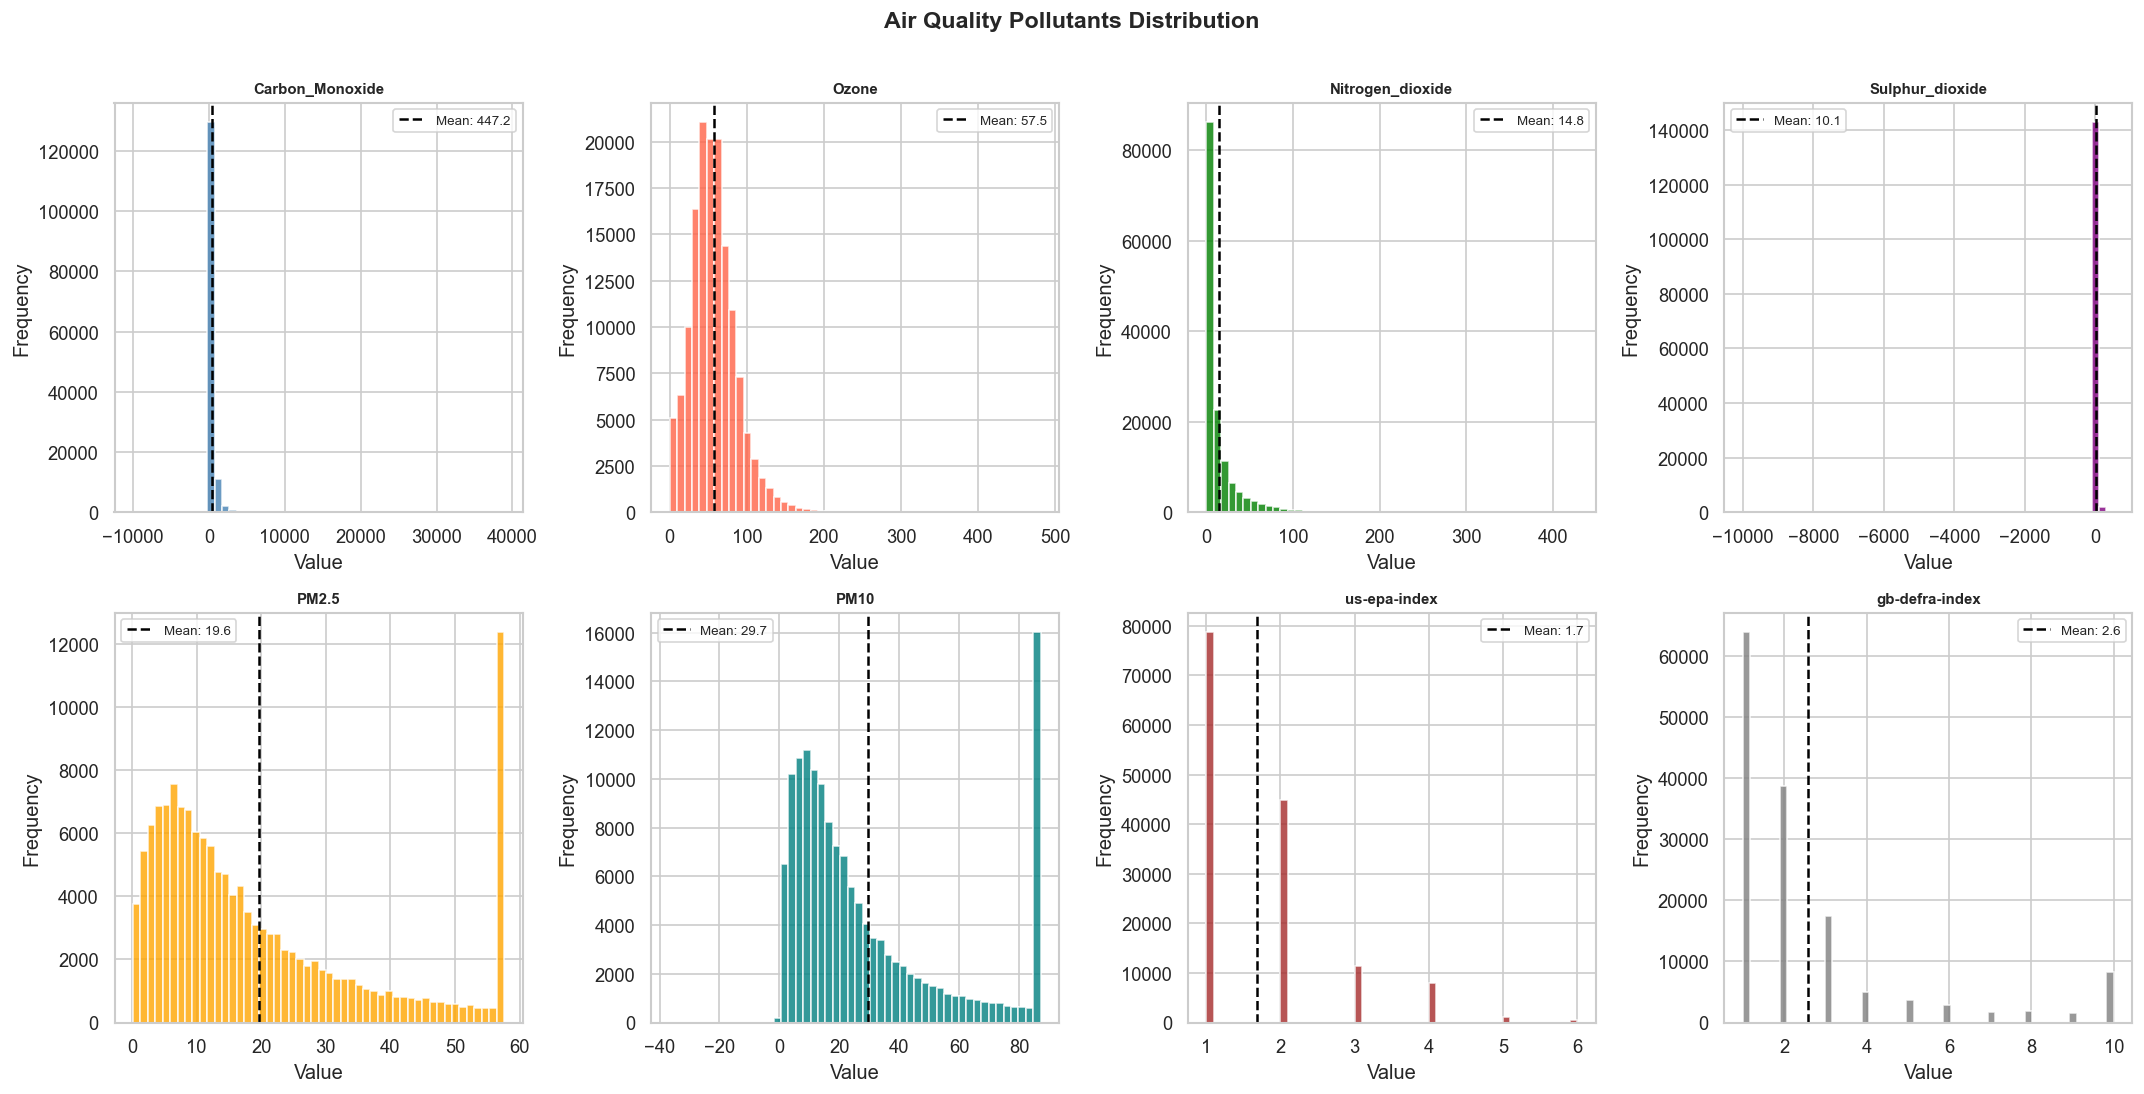

 Saved: 33_air_quality_distributions.png


In [9]:
# Distribution of key pollutants
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
colors = ['steelblue','tomato','green','purple',
          'orange','teal','brown','gray']

for i, col in enumerate(aq_cols):
    axes[i].hist(df[col].dropna(), bins=50,
                 color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('air_quality_', ''),
                      fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='black',
                    linestyle='--', linewidth=1.5,
                    label=f"Mean: {df[col].mean():.1f}")
    axes[i].legend(fontsize=8)

plt.suptitle('Air Quality Pollutants Distribution',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '33_air_quality_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 33_air_quality_distributions.png")

## 2. Air Quality by Continent

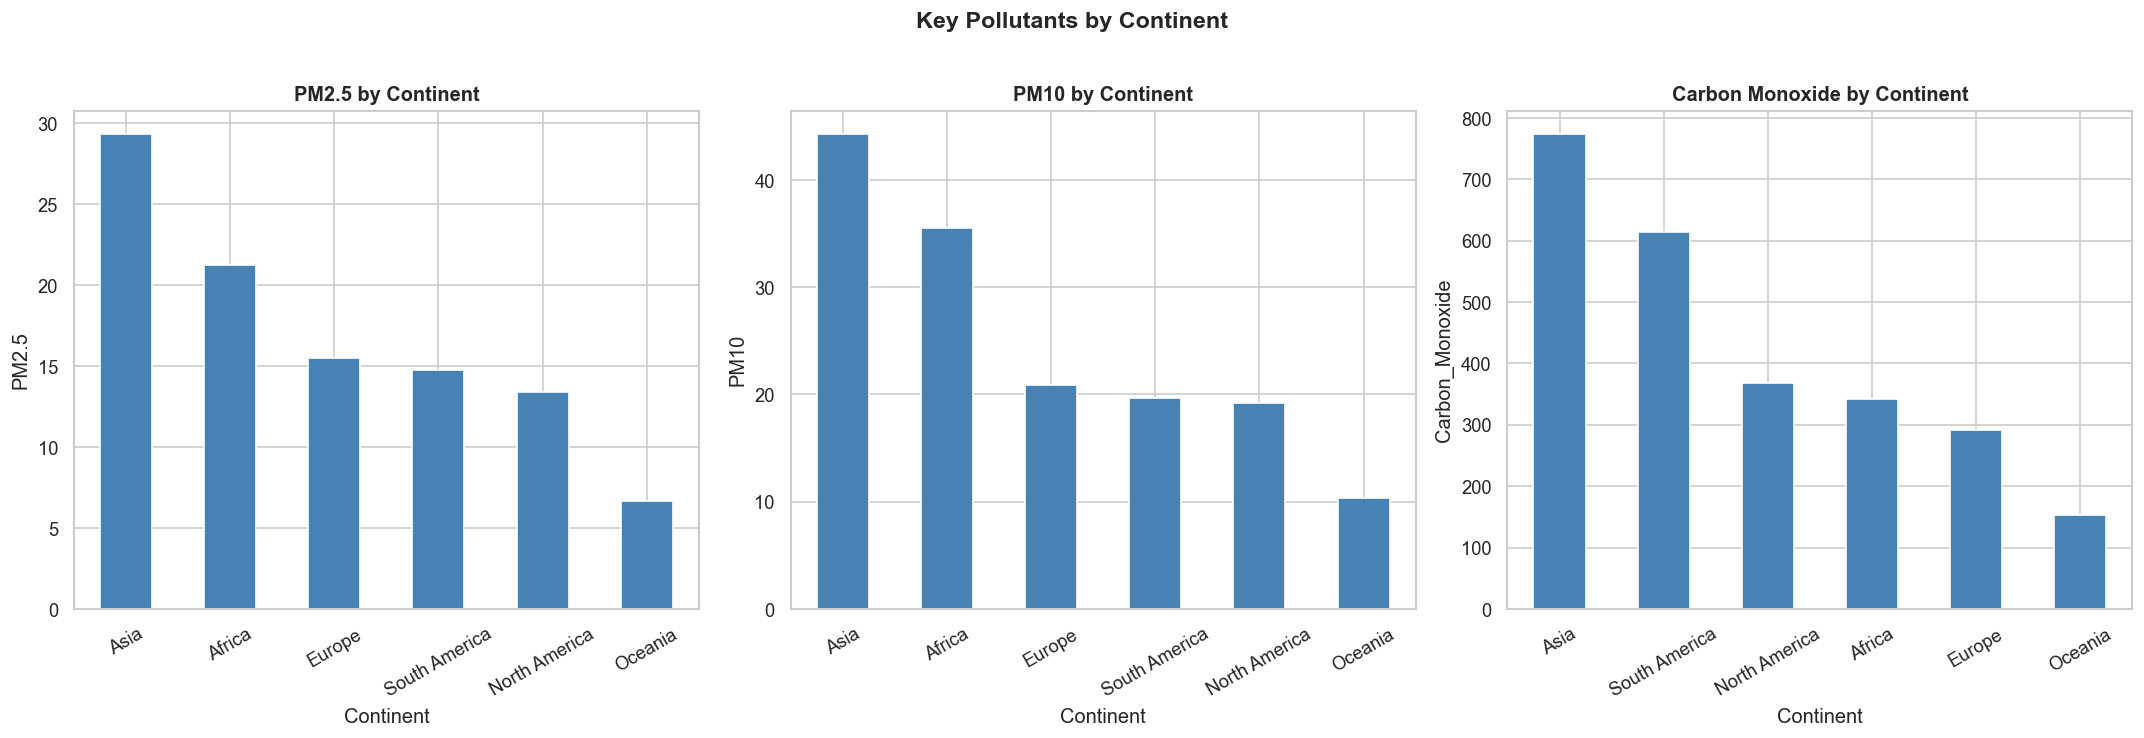

Saved: 34_air_quality_by_continent.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

key_pollutants = ['air_quality_PM2.5', 'air_quality_PM10',
                  'air_quality_Carbon_Monoxide']
titles = ['PM2.5 by Continent', 'PM10 by Continent',
          'Carbon Monoxide by Continent']

for i, (col, title) in enumerate(zip(key_pollutants, titles)):
    continent_aq = df.groupby('continent')[col].mean().sort_values(ascending=False)
    continent_aq.plot(kind='bar', ax=axes[i],
                      color='steelblue', edgecolor='white')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Continent')
    axes[i].set_ylabel(col.replace('air_quality_', ''))
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Key Pollutants by Continent',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '34_air_quality_by_continent.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 34_air_quality_by_continent.png")

## 3. Air Quality vs Weather Parameters Correlation

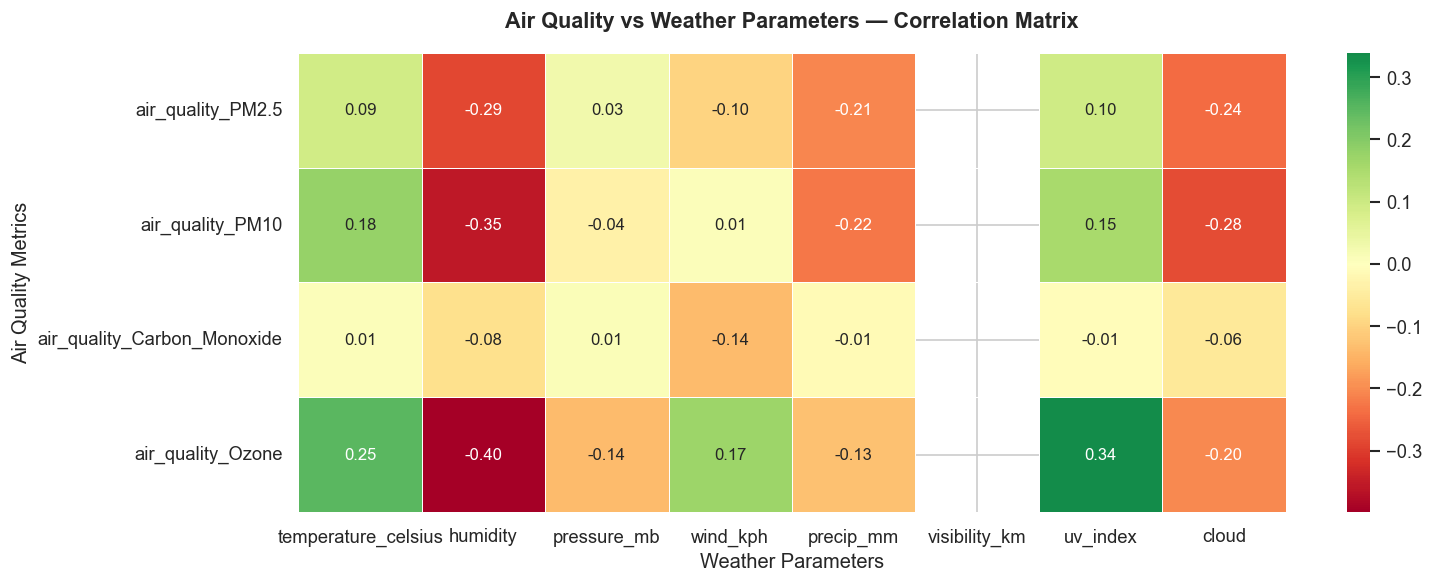

 Saved: 35_aq_weather_correlation.png


In [11]:
# Correlation matrix between AQ and weather
combined_cols = weather_cols + ['air_quality_PM2.5',
                                 'air_quality_PM10',
                                 'air_quality_Carbon_Monoxide',
                                 'air_quality_Ozone']
corr = df[combined_cols].corr()

# Extract only AQ vs weather correlations
aq_weather_corr = corr.loc[
    ['air_quality_PM2.5', 'air_quality_PM10',
     'air_quality_Carbon_Monoxide', 'air_quality_Ozone'],
    weather_cols
]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(aq_weather_corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 10})
ax.set_title('Air Quality vs Weather Parameters — Correlation Matrix',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Weather Parameters')
ax.set_ylabel('Air Quality Metrics')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '35_aq_weather_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 35_aq_weather_correlation.png")

## 4. PM2.5 vs Key Weather Parameters

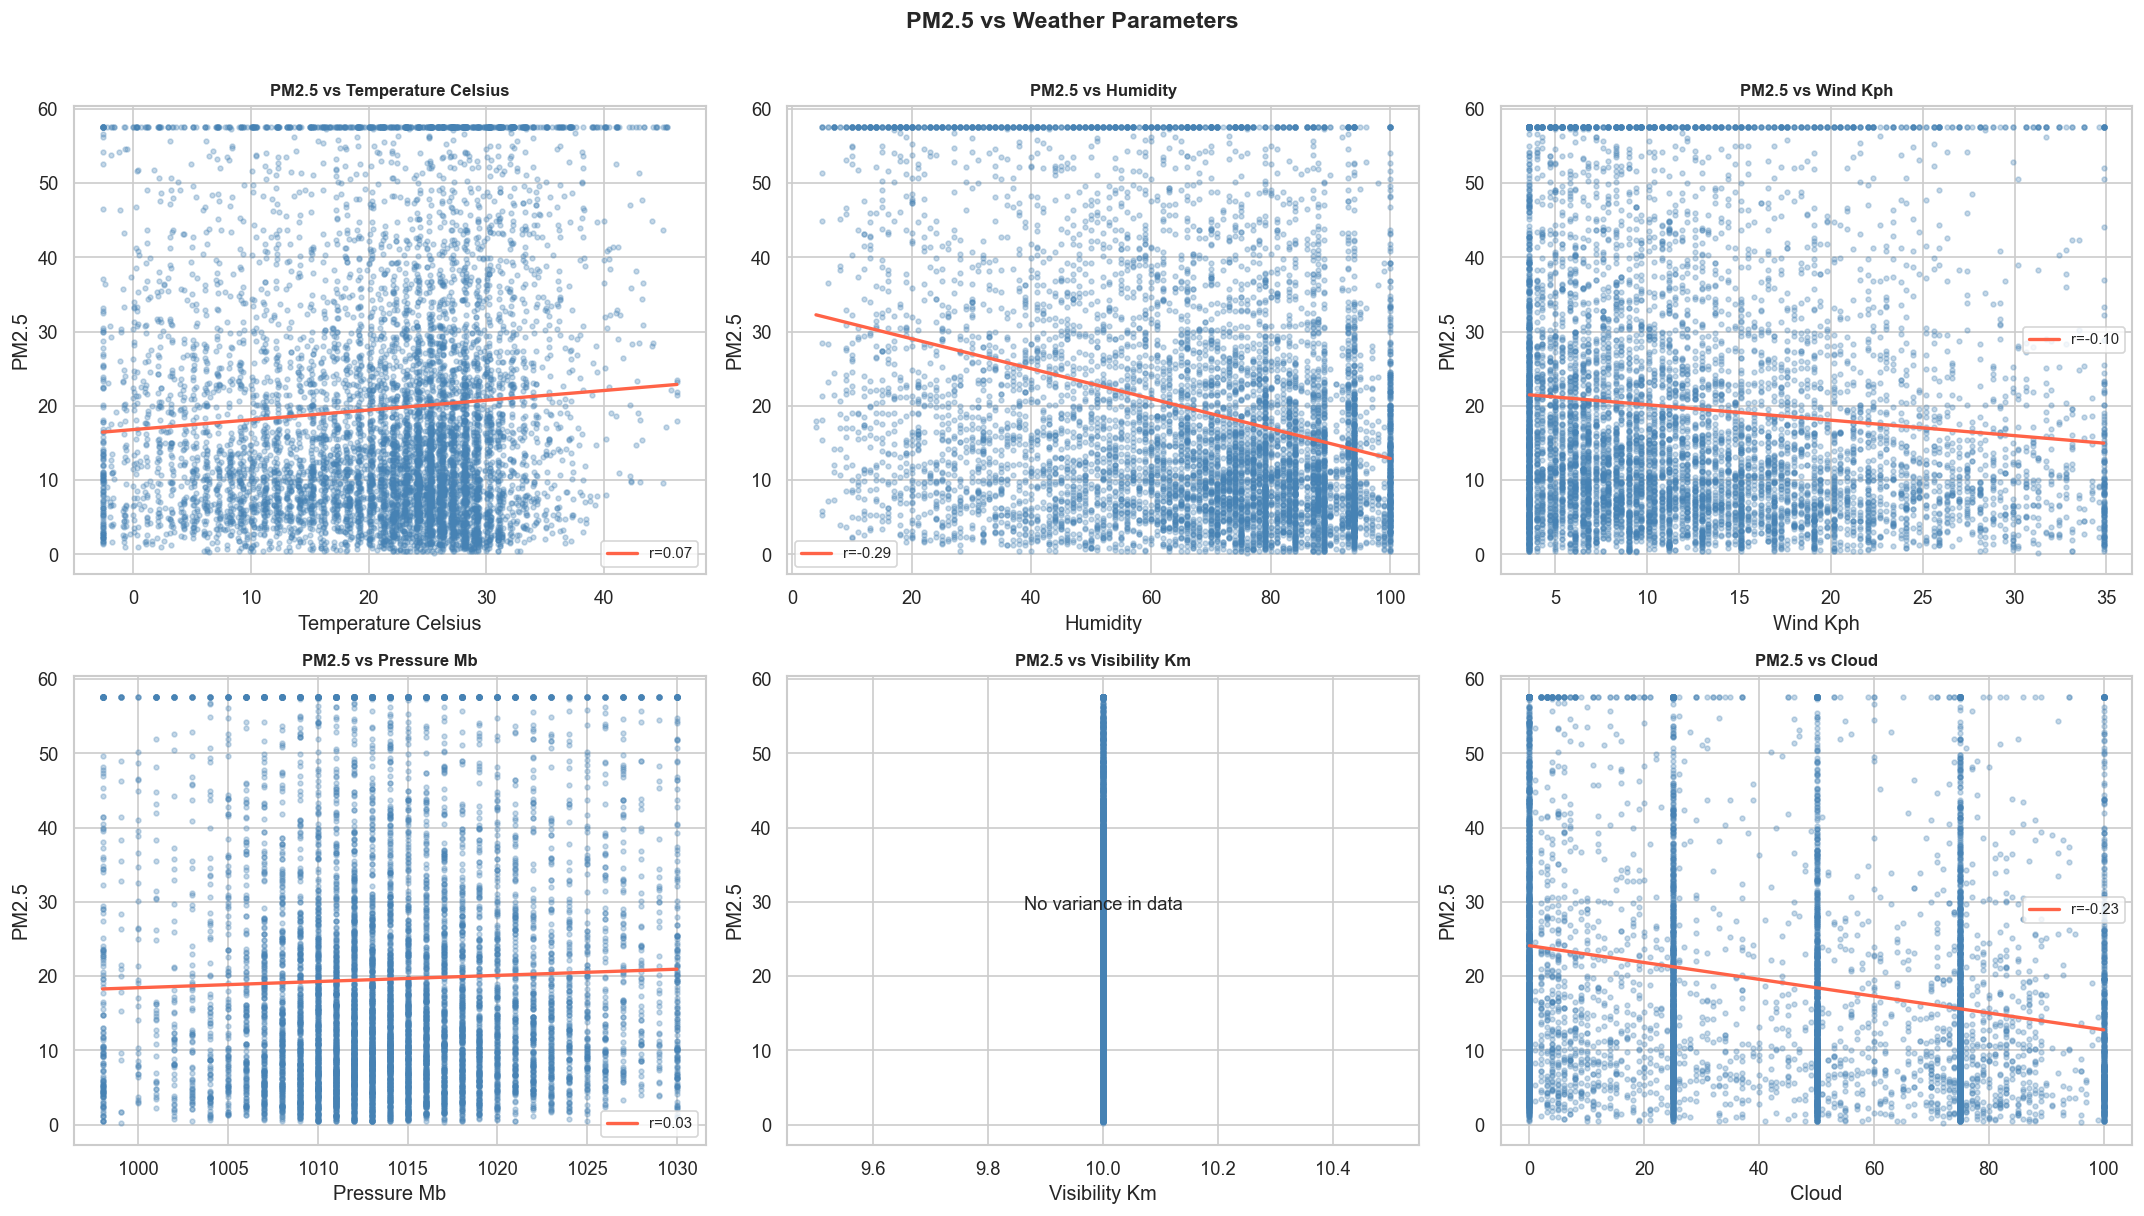

 Saved: 36_pm25_vs_weather.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

scatter_params = ['temperature_celsius', 'humidity',
                  'wind_kph', 'pressure_mb',
                  'visibility_km', 'cloud']

sample = df.sample(8000, random_state=42)

for i, param in enumerate(scatter_params):
    axes[i].scatter(sample[param], sample['air_quality_PM2.5'],
                    alpha=0.3, s=8, color='steelblue')

    # Regression line — only if x has variance
    mask = sample[[param, 'air_quality_PM2.5']].notna().all(axis=1)
    x_vals = sample.loc[mask, param]
    y_vals = sample.loc[mask, 'air_quality_PM2.5']

    if x_vals.nunique() > 1:
        slope, intercept, r_val, _, _ = stats.linregress(x_vals, y_vals)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        axes[i].plot(x_line, slope * x_line + intercept,
                     color='tomato', linewidth=2,
                     label=f'r={r_val:.2f}')
        axes[i].legend(fontsize=9)
    else:
        axes[i].text(0.5, 0.5, 'No variance in data',
                     transform=axes[i].transAxes, ha='center')

    axes[i].set_title(f'PM2.5 vs {param.replace("_"," ").title()}',
                      fontweight='bold', fontsize=10)
    axes[i].set_xlabel(param.replace('_', ' ').title())
    axes[i].set_ylabel('PM2.5')

plt.suptitle('PM2.5 vs Weather Parameters',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '36_pm25_vs_weather.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 36_pm25_vs_weather.png")

## 5. Air Quality Index Distribution

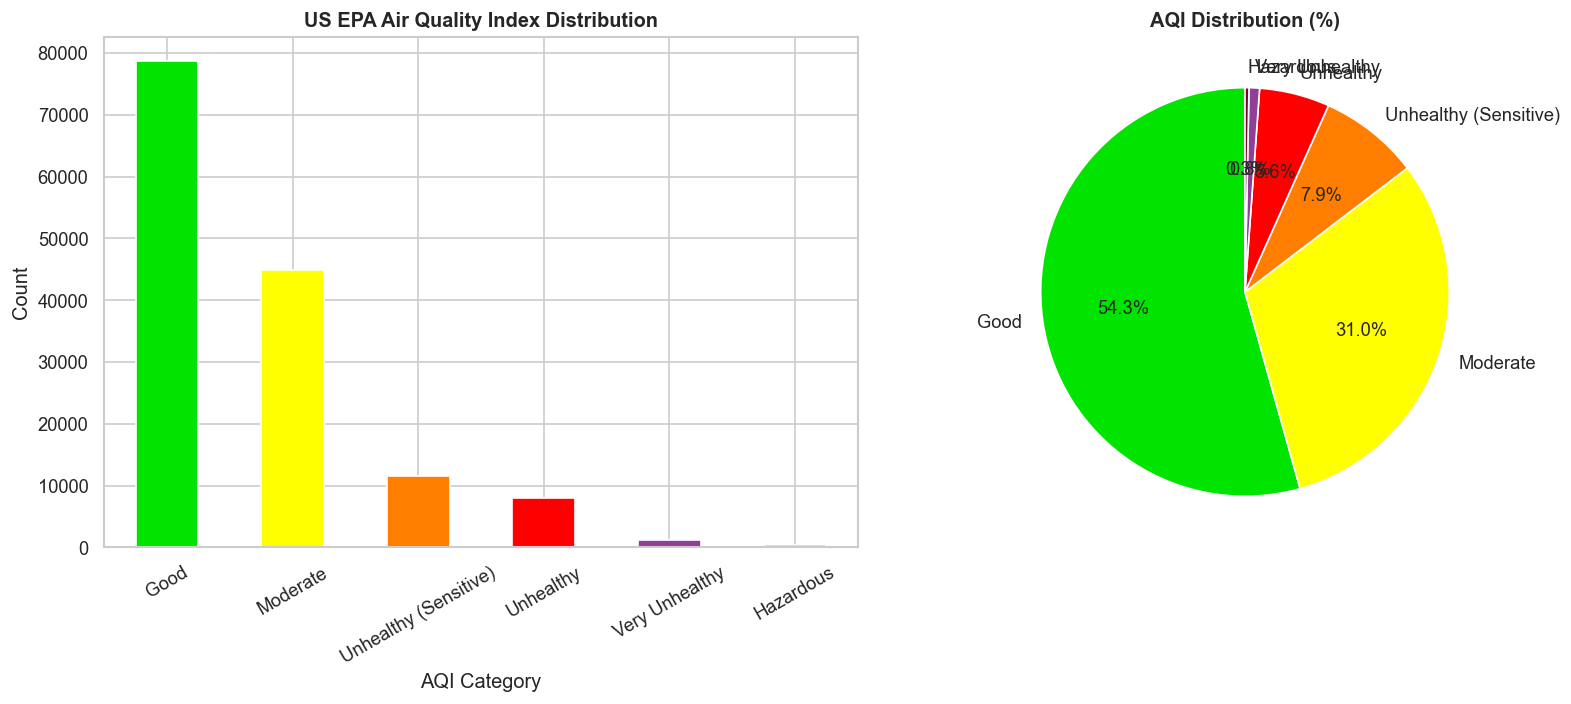

Saved: 37_aqi_distribution.png


In [ ]:
# US EPA Index categories
epa_labels = {
    1: 'Good', 2: 'Moderate', 3: 'Unhealthy (Sensitive)',
    4: 'Unhealthy', 5: 'Very Unhealthy', 6: 'Hazardous'
}
epa_colors = {
    1: '#00E400', 2: '#FFFF00', 3: '#FF7E00',
    4: '#FF0000', 5: '#8F3F97', 6: '#7E0023'
}

epa_counts = df['air_quality_us-epa-index'].value_counts().sort_index()
epa_counts.index = [epa_labels.get(i, str(i)) for i in epa_counts.index]
colors_list = [epa_colors.get(i, 'gray')
               for i in df['air_quality_us-epa-index'].value_counts().sort_index().index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
epa_counts.plot(kind='bar', ax=axes[0],
                color=colors_list, edgecolor='white')
axes[0].set_title('US EPA Air Quality Index Distribution',
                   fontweight='bold')
axes[0].set_xlabel('AQI Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(epa_counts.values, labels=epa_counts.index,
            colors=colors_list, autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('AQI Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '37_aqi_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 37_aqi_distribution.png")

## 6. Air Quality Trend Over Time

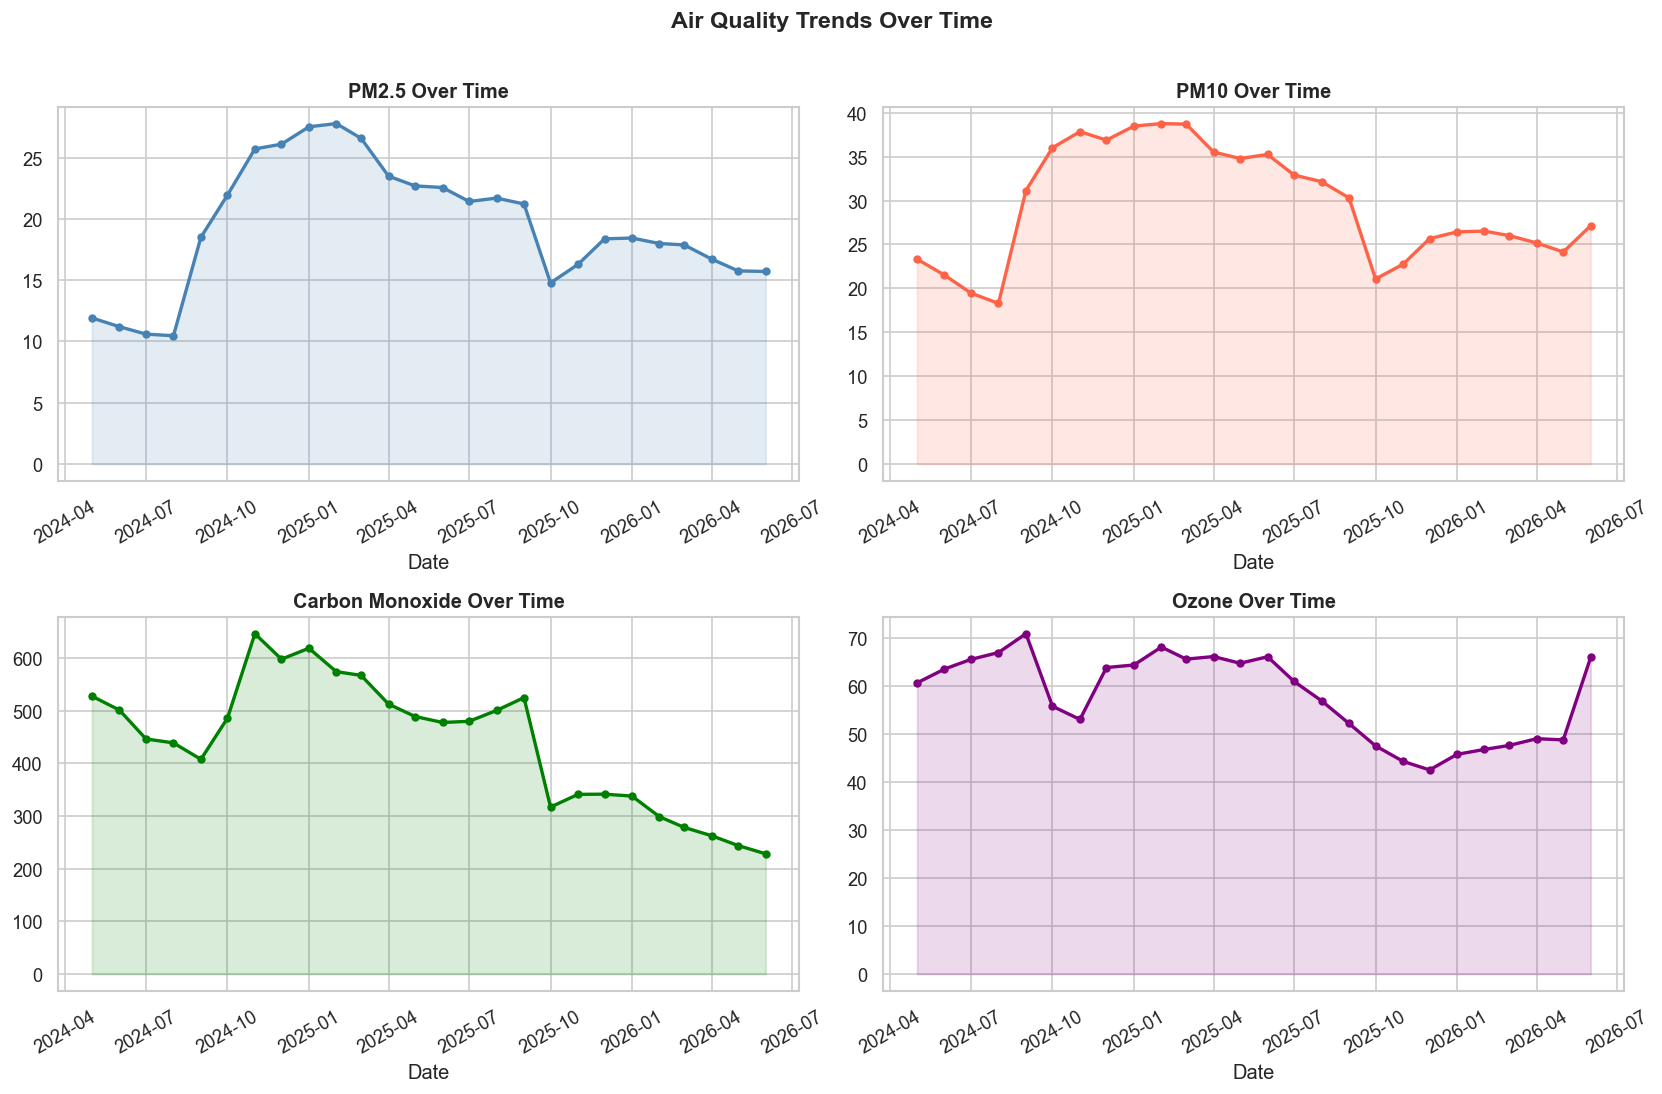

Saved: 38_air_quality_trends.png


In [ ]:
monthly_aq = df.groupby(df['last_updated'].dt.to_period('M')).agg(
    pm25=('air_quality_PM2.5', 'mean'),
    pm10=('air_quality_PM10', 'mean'),
    co=('air_quality_Carbon_Monoxide', 'mean'),
    ozone=('air_quality_Ozone', 'mean')
).reset_index()
monthly_aq['last_updated'] = monthly_aq['last_updated'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

pollutants = ['pm25', 'pm10', 'co', 'ozone']
titles = ['PM2.5 Over Time', 'PM10 Over Time',
          'Carbon Monoxide Over Time', 'Ozone Over Time']
colors = ['steelblue', 'tomato', 'green', 'purple']

for i, (col, title, color) in enumerate(zip(pollutants, titles, colors)):
    axes[i].plot(monthly_aq['last_updated'], monthly_aq[col],
                 color=color, linewidth=2, marker='o', markersize=4)
    axes[i].fill_between(monthly_aq['last_updated'],
                          monthly_aq[col], alpha=0.15, color=color)
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('Date')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Air Quality Trends Over Time',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '38_air_quality_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 38_air_quality_trends.png")